In [1]:
# IMPORTS


import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.ml.functions import vector_to_array
from pyspark.ml.feature import VectorAssembler, MinMaxScaler
from pyspark.sql import functions as F
from pyspark.sql import SparkSession

In [2]:
spark = (SparkSession.builder
         .appName("TeamsAnalysis")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.executor.memory", "4g")
         .getOrCreate())


In [3]:
df = (spark.read
      .option("sep", "\t")
      .option("inferSchema", True)
      .csv("outputs/clean"))

#df.show(5)
#df.printSchema()



In [4]:
df = df.toDF(
    "gameid", "date", "type", "teamid", "team",
    "home", "away", "min", "pts",
    "fgm", "fga", "fg_pct",
    "tpm", "tpa", "tp_pct",
    "ftm", "fta", "ft_pct",
    "oreb", "dreb", "reb",
    "ast", "tov", "stl", "blk",
    "pf", "plusminus", "win", "season"
)

df.show(5)


+--------+----------+-------+----------+----+----+----+---+---+---+---+------+---+---+------+---+---+------+----+----+---+---+---+---+---+---+---------+---+------+
|  gameid|      date|   type|    teamid|team|home|away|min|pts|fgm|fga|fg_pct|tpm|tpa|tp_pct|ftm|fta|ft_pct|oreb|dreb|reb|ast|tov|stl|blk| pf|plusminus|win|season|
+--------+----------+-------+----------+----+----+----+---+---+---+---+------+---+---+------+---+---+------+----+----+---+---+---+---+---+---+---------+---+------+
|29600001|1996-11-01|regular|1610612738| BOS|NULL|NULL| 48| 98| 38| 84|  45.2|  8| 20|  40.0| 14| 23|  60.9|  14|  22| 36| 20| 18| 10|  2| 33|       -9|  0|  1997|
|29600001|1996-11-01|regular|1610612741| CHI|NULL|NULL| 48|107| 42| 74|  56.8|  1| 13|   7.7| 22| 32|  68.8|   8|  29| 37| 28| 19|  7|  8| 23|        9|  1|  1997|
|29600002|1996-11-01|regular|1610612739| CLE|NULL|NULL| 48| 90| 34| 72|  47.2|  5| 10|  50.0| 17| 20|  85.0|  12|  23| 35| 16| 15| 11|  1| 24|       13|  1|  1997|
|29600002|1996-1

In [5]:
df_a = df.alias("a")
df_b = df.alias("b")

games = (df_a.join(df_b,
                   (df_a.gameid == df_b.gameid) &
                   (df_a.teamid != df_b.teamid))
              .select(
                  F.col("a.teamid").alias("team_id"),
                  F.col("b.teamid").alias("opponent_id"),
                  F.col("a.pts").alias("team_pts"),
                  F.col("b.pts").alias("opp_pts"),
                  F.col("a.plusminus").alias("team_plusminus"),
                  F.col("a.win").alias("team_win"),
                  F.col("a.season").alias("season")
              ))

games.show(5)
games.printSchema()


+----------+-----------+--------+-------+--------------+--------+------+
|   team_id|opponent_id|team_pts|opp_pts|team_plusminus|team_win|season|
+----------+-----------+--------+-------+--------------+--------+------+
|1610612738| 1610612741|      98|    107|            -9|       0|  1997|
|1610612741| 1610612738|     107|     98|             9|       1|  1997|
|1610612739| 1610612751|      90|     77|            13|       1|  1997|
|1610612751| 1610612739|      77|     90|           -13|       0|  1997|
|1610612749| 1610612755|     111|    103|             8|       1|  1997|
+----------+-----------+--------+-------+--------------+--------+------+
only showing top 5 rows
root
 |-- team_id: integer (nullable = true)
 |-- opponent_id: integer (nullable = true)
 |-- team_pts: integer (nullable = true)
 |-- opp_pts: integer (nullable = true)
 |-- team_plusminus: integer (nullable = true)
 |-- team_win: integer (nullable = true)
 |-- season: integer (nullable = true)



In [6]:
games = games.withColumn(
    "rating",
    (F.col("team_pts") - F.col("opp_pts") + 60) / 60
)

games.select("rating").describe().show()


+-------+--------------------+
|summary|              rating|
+-------+--------------------+
|  count|               70850|
|   mean|                 1.0|
| stddev| 0.23108494513027414|
|    min|-0.21666666666666667|
|    max|   2.216666666666667|
+-------+--------------------+



In [7]:
pivot = games.groupBy("team_id") \
             .pivot("opponent_id") \
             .avg("rating") \
             .fillna(0)

#pivot.show(5)


In [8]:
opponent_cols = pivot.columns[1:]  # all opponent columns

assembler = VectorAssembler(
    inputCols=opponent_cols,
    outputCol="features"
)

matrix = assembler.transform(pivot)

#matrix.select("team_id", "features").show(5, truncate=False)

In [9]:
matrix = matrix.withColumn("vec", vector_to_array("features"))
#matrix.select("team_id", "vec").show(5, truncate=False)



In [10]:
matrix = matrix.withColumn(
    "norm",
    F.sqrt(
        F.expr("aggregate(vec, 0D, (acc, x) -> acc + x*x)")
    )
)

matrix.select("team_id", "norm").show(5)


+----------+-----------------+
|   team_id|             norm|
+----------+-----------------+
|1610612751|5.192674665581652|
|1610612743|5.459931450337977|
|1610612738| 5.57203900484027|
|1610612745|5.523616030627166|
|1610612765|5.335470678054073|
+----------+-----------------+
only showing top 5 rows


In [11]:
m1 = matrix.select(
    F.col("team_id").alias("team_a"),
    F.col("vec").alias("vec_a"),
    F.col("norm").alias("norm_a")
)

m2 = matrix.select(
    F.col("team_id").alias("team_b"),
    F.col("vec").alias("vec_b"),
    F.col("norm").alias("norm_b")
)

similarities = (
    m1.crossJoin(m2)
      .filter(F.col("team_a") != F.col("team_b"))
      .withColumn(
          "dot",
          F.expr("aggregate(zip_with(vec_a, vec_b, (x, y) -> x * y), 0D, (acc, v) -> acc + v)")
      )
      .withColumn(
          "cosine_similarity",
          F.col("dot") / (F.col("norm_a") * F.col("norm_b"))
      )
)

similarities.show(10)


+----------+--------------------+-----------------+----------+--------------------+------------------+------------------+------------------+
|    team_a|               vec_a|           norm_a|    team_b|               vec_b|            norm_b|               dot| cosine_similarity|
+----------+--------------------+-----------------+----------+--------------------+------------------+------------------+------------------+
|1610612751|[0.98632075471698...|5.192674665581652|1610612743|[1.03867924528301...| 5.459931450337977|27.337961220301224|0.9642459405617428|
|1610612751|[0.98632075471698...|5.192674665581652|1610612738|[1.0348, 0.0, 1.0...|  5.57203900484027|27.928000435585293|0.9652383774364732|
|1610612751|[0.98632075471698...|5.192674665581652|1610612745|[1.05679012345679...| 5.523616030627166| 27.66737491788495|0.9646135541767125|
|1610612751|[0.98632075471698...|5.192674665581652|1610612765|[1.02321428571428...| 5.335470678054073|26.697187609188127|0.9636108072486137|
|1610612751|[

CF Recommendations 

In [12]:
# Keep only what we need and maybe rename
cf_sim = similarities.select(
    "team_a",
    "team_b",
    F.col("cosine_similarity").alias("cf_sim")
)

# For each team_a, collect and sort team_b by similarity
cf_recs = (cf_sim
    .groupBy("team_a")
    .agg(
        F.sort_array(
            F.collect_list(F.struct(F.col("cf_sim"), F.col("team_b"))),
            asc=False
        ).alias("neighbours")
    )
)

#cf_recs.show(5, truncate=False)


In [13]:
top_k = 5

cf_topk = (cf_recs
    .select(
        "team_a",
        F.slice("neighbours", 1, top_k).alias("topk")
    )
    .select(
        "team_a",
        F.posexplode("topk").alias("rank", "rec")
    )
    .select(
        "team_a",
        (F.col("rank") + 1).alias("rank"),
        F.col("rec.team_b").alias("similar_team"),
        F.col("rec.cf_sim").alias("similarity")
    )
)

#cf_topk.show(20, truncate=False)


 Build Content-Based (CB) team profiles

In [14]:
from pyspark.sql import functions as F

team_profile = (df
    .groupBy("teamid", "team")  # you can also include season if you want season-specific profiles
    .agg(
        F.avg("pts").alias("avg_pts"),
        F.avg("reb").alias("avg_reb"),
        F.avg("ast").alias("avg_ast"),
        F.avg("plusminus").alias("avg_plusminus"),
        F.avg("win").alias("win_rate")
    )
)

team_profile.show(5, truncate=False)


+----------+----+------------------+------------------+------------------+-------------------+-------------------+
|teamid    |team|avg_pts           |avg_reb           |avg_ast           |avg_plusminus      |win_rate           |
+----------+----+------------------+------------------+------------------+-------------------+-------------------+
|1610612755|PHI |100.38982338099242|42.71951219512195 |22.13919259882254 |-1.016820857863751 |0.46761984861227923|
|1610612745|HOU |103.38019303399076|43.27654217373059 |21.714645404951742|1.1917750734368444 |0.5383969785984054 |
|1610612749|MIL |103.01054407423028|42.87431463517503 |22.797975537747785|0.24504428511176718|0.5018979333614508 |
|1610612750|MIN |102.42405884898312|42.599740372133276|23.34400692340978 |-1.0623106880138469|0.4465599307659022 |
|1610612760|OKC |107.84804246848043|44.73125414731254 |21.914399469143994|2.6025215660252154 |0.5792966157929662 |
+----------+----+------------------+------------------+------------------+------

In [15]:
cb_features = ["avg_pts", "avg_reb", "avg_ast", "avg_plusminus", "win_rate"]

assembler_cb = VectorAssembler(
    inputCols=cb_features,
    outputCol="cb_features_raw"
)

team_profile = assembler_cb.transform(team_profile)

# Optional: scale features between 0 and 1 for nicer geometry
scaler = MinMaxScaler(inputCol="cb_features_raw", outputCol="cb_features")
scaler_model = scaler.fit(team_profile)
team_profile_scaled = scaler_model.transform(team_profile)

team_profile_scaled.select("teamid", "team", "cb_features").show(5, truncate=False)


+----------+----+-------------------------------------------------------------------------------------------------+
|teamid    |team|cb_features                                                                                      |
+----------+----+-------------------------------------------------------------------------------------------------+
|1610612755|PHI |[0.4794499106525594,0.5455766312635201,0.5664788753623428,0.5845991187403802,0.627283614737188]  |
|1610612745|HOU |[0.6574683035995466,0.6714016353555788,0.49786436951460256,0.7864702809104467,0.8121903604787213]|
|1610612749|MIL |[0.6354628924273502,0.580544260298123,0.6729501145269434,0.699936731793193,0.7168358345356488]   |
|1610612750|MIN |[0.6005490960072429,0.5185219112369495,0.7611986632052714,0.580441235105273,0.5722641349232855]  |
|1610612760|OKC |[0.9234419016995262,1.0,0.53014823949067,0.9154160196714765,0.919041525779406]                   |
+----------+----+-------------------------------------------------------

In [16]:
team_profile_scaled = team_profile_scaled.withColumn(
    "cb_vec",
    vector_to_array("cb_features")
)

team_profile_scaled = team_profile_scaled.withColumn(
    "cb_norm",
    F.sqrt(F.expr("aggregate(cb_vec, 0D, (acc, x) -> acc + x*x)"))
)

team_profile_scaled.select("teamid", "cb_vec", "cb_norm").show(5, truncate=False)


+----------+-----------------------------------------------------------------------------------------------------+------------------+
|teamid    |cb_vec                                                                                               |cb_norm           |
+----------+-----------------------------------------------------------------------------------------------------+------------------+
|1610612755|[0.4794499106525594, 0.5455766312635201, 0.5664788753623428, 0.5845991187403802, 0.627283614737188]  |1.2584376252270768|
|1610612745|[0.6574683035995466, 0.6714016353555788, 0.49786436951460256, 0.7864702809104467, 0.8121903604787213]|1.5521283262147805|
|1610612749|[0.6354628924273502, 0.580544260298123, 0.6729501145269434, 0.699936731793193, 0.7168358345356488]   |1.4823871372373723|
|1610612750|[0.6005490960072429, 0.5185219112369495, 0.7611986632052714, 0.580441235105273, 0.5722641349232855]  |1.3687022545255993|
|1610612760|[0.9234419016995262, 1.0, 0.53014823949067, 0.9154

In [17]:
cb1 = team_profile_scaled.select(
    F.col("teamid").alias("team_a"),
    F.col("cb_vec").alias("cb_vec_a"),
    F.col("cb_norm").alias("cb_norm_a")
)

cb2 = team_profile_scaled.select(
    F.col("teamid").alias("team_b"),
    F.col("cb_vec").alias("cb_vec_b"),
    F.col("cb_norm").alias("cb_norm_b")
)

cb_similarities = (
    cb1.crossJoin(cb2)
       .filter(F.col("team_a") != F.col("team_b"))
       .withColumn(
           "cb_dot",
           F.expr("aggregate(zip_with(cb_vec_a, cb_vec_b, (x, y) -> x * y), 0D, (acc, v) -> acc + v)")
       )
       .withColumn(
           "cb_sim",
           F.col("cb_dot") / (F.col("cb_norm_a") * F.col("cb_norm_b"))
       )
)

cb_similarities.select("team_a", "team_b", "cb_sim").show(10, truncate=False)


+----------+----------+------------------+
|team_a    |team_b    |cb_sim            |
+----------+----------+------------------+
|1610612755|1610612745|0.9895255258816101|
|1610612755|1610612749|0.9978375965845091|
|1610612755|1610612750|0.9871695798881882|
|1610612755|1610612760|0.97634551854005  |
|1610612755|1610612744|0.9878743246308872|
|1610612755|1610612756|0.9831260607930468|
|1610612755|1610612758|0.9830949088663686|
|1610612755|1610612753|0.9966104460176778|
|1610612755|1610612760|0.925130889574854 |
|1610612755|1610612739|0.9945351763713252|
+----------+----------+------------------+
only showing top 10 rows


 Build the Hybrid Recommender (CF + CB)

In [18]:
# Make sure both are using the same dtype (int/int or string/string)
cf_sim_simple = cf_sim.select("team_a", "team_b", "cf_sim")
cb_sim_simple = cb_similarities.select("team_a", "team_b", "cb_sim")

hybrid = (cf_sim_simple
    .join(cb_sim_simple, on=["team_a", "team_b"], how="inner")
)


In [19]:
# Compute global mins/maxes
cf_stats = hybrid.agg(F.min("cf_sim").alias("cf_min"), F.max("cf_sim").alias("cf_max")).first()
cb_stats = hybrid.agg(F.min("cb_sim").alias("cb_min"), F.max("cb_sim").alias("cb_max")).first()

cf_min, cf_max = cf_stats["cf_min"], cf_stats["cf_max"]
cb_min, cb_max = cb_stats["cb_min"], cb_stats["cb_max"]

hybrid = (hybrid
    .withColumn("cf_norm", (F.col("cf_sim") - cf_min) / (cf_max - cf_min))
    .withColumn("cb_norm", (F.col("cb_sim") - cb_min) / (cb_max - cb_min))
)


In [20]:
alpha = 0.6  # more weight on CF

hybrid = hybrid.withColumn(
    "hybrid_score",
    alpha * F.col("cf_norm") + (1 - alpha) * F.col("cb_norm")
)

hybrid.select("team_a", "team_b", "cf_norm", "cb_norm", "hybrid_score").show(10, truncate=False)


+----------+----------+-------------------+------------------+------------------+
|team_a    |team_b    |cf_norm            |cb_norm           |hybrid_score      |
+----------+----------+-------------------+------------------+------------------+
|1610612751|1610612743|0.39274874035867446|0.9874947492280653|0.6306471439064308|
|1610612751|1610612743|0.39274874035867446|0.931991970838335 |0.6084460325505388|
|1610612751|1610612738|0.5371199492366462 |0.9330282522252028|0.6954832704320688|
|1610612751|1610612738|0.5371199492366462 |0.9714938205235314|0.7108694977514003|
|1610612751|1610612745|0.4462260176994459 |0.9468155270344923|0.6464618214334645|
|1610612751|1610612745|0.4462260176994459 |0.9287176416685341|0.6392226672870812|
|1610612751|1610612765|0.3003549906402991 |0.9326033761974932|0.5532543448631768|
|1610612751|1610612765|0.3003549906402991 |0.9708760025855748|0.5685633954184094|
|1610612751|1610612748|0.47390725129122724|0.8578734295756353|0.6274937226049905|
|1610612751|1610

In [21]:
hybrid_recs = (hybrid
    .groupBy("team_a")
    .agg(
        F.sort_array(
            F.collect_list(F.struct("hybrid_score", "team_b")),
            asc=False
        ).alias("recs")
    )
)

top_k = 5
hybrid_topk = (hybrid_recs
    .select("team_a", F.slice("recs", 1, top_k).alias("topk"))
    .select("team_a", F.posexplode("topk").alias("rank", "rec"))
    .select(
        "team_a",
        (F.col("rank") + 1).alias("rank"),
        F.col("rec.team_b").alias("similar_team"),
        F.col("rec.hybrid_score").alias("score")
    )
)

hybrid_topk.show(10, truncate=False)


+----------+----+------------+------------------+
|team_a    |rank|similar_team|score             |
+----------+----+------------+------------------+
|1610612751|1   |1610612759  |0.8017159607444553|
|1610612751|2   |1610612759  |0.7770160080874025|
|1610612751|3   |1610612738  |0.7108694977514003|
|1610612751|4   |1610612760  |0.6992617249813765|
|1610612751|5   |1610612762  |0.6971600672000704|
|1610612743|1   |1610612759  |0.9080366994753526|
|1610612743|2   |1610612760  |0.8604340402250911|
|1610612743|3   |1610612738  |0.8472139112332586|
|1610612743|4   |1610612760  |0.8376504528422853|
|1610612743|5   |1610612747  |0.8294101130537312|
+----------+----+------------+------------------+
only showing top 10 rows


 Greatest teams given X features

In [22]:
team_strength = (hybrid
    .groupBy("team_a")
    .agg(F.avg("hybrid_score").alias("avg_hybrid_score"))
    .orderBy(F.col("avg_hybrid_score").desc())
)

# add team names
team_strength_named = (team_strength
    .join(team_profile.select("teamid", "team"), team_strength.team_a == team_profile.teamid, "left")
    .select("team_a", "team", "avg_hybrid_score")
    .orderBy(F.col("avg_hybrid_score").desc())
)

team_strength_named.show(10, truncate=False)


+----------+----+------------------+
|team_a    |team|avg_hybrid_score  |
+----------+----+------------------+
|1610612759|SAS |0.8613290920607247|
|1610612738|BOS |0.7849826463973846|
|1610612762|UTA |0.7760498993013573|
|1610612747|LAL |0.7672807993588687|
|1610612760|SEA |0.7665056654601027|
|1610612760|OKC |0.7665056654601027|
|1610612742|DAL |0.7602306701930436|
|1610612748|MIA |0.7473248228012055|
|1610612745|HOU |0.7464115677848002|
|1610612754|IND |0.7331703823017817|
+----------+----+------------------+
only showing top 10 rows


PLOTTING 

### 1. Plot: Top-10 Teams by Hybrid Score

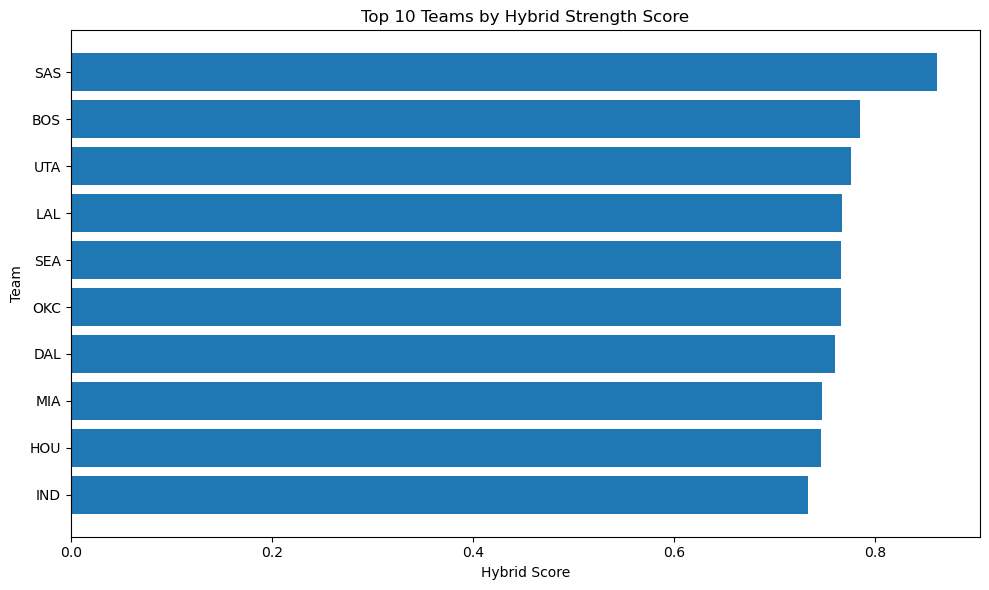

In [23]:
# Convert Spark DataFrame → Pandas
top10 = team_strength_named.orderBy("avg_hybrid_score", ascending=False).limit(10).toPandas()

plt.figure(figsize=(10, 6))
plt.barh(top10['team'][::-1], top10['avg_hybrid_score'][::-1])
plt.title("Top 10 Teams by Hybrid Strength Score")
plt.xlabel("Hybrid Score")
plt.ylabel("Team")
plt.tight_layout()
plt.show()


### 2. Heatmap of Team Similarity (CF)

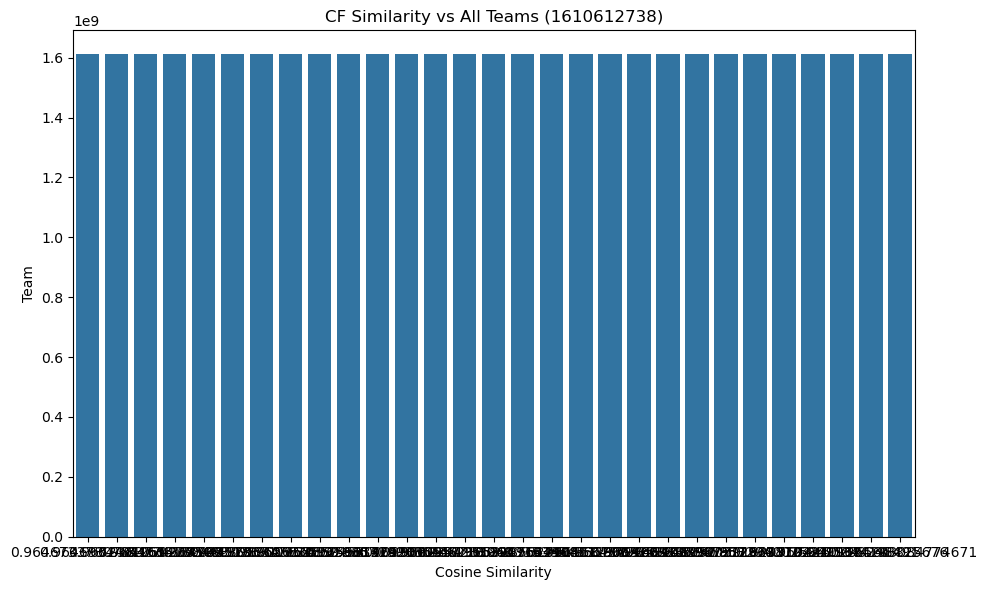

In [25]:
team = "1610612738"   # Example: Boston (change as you like)

sim_pd = (similarities
    .filter(F.col("team_a") == team)
    .select("team_b", "cosine_similarity")
    .toPandas()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=sim_pd, x="cosine_similarity", y="team_b")
plt.title(f"CF Similarity vs All Teams ({team})")
plt.xlabel("Cosine Similarity")
plt.ylabel("Team")
plt.tight_layout()
plt.show()


###  3. Radar Chart for a Single Team's CB Profile

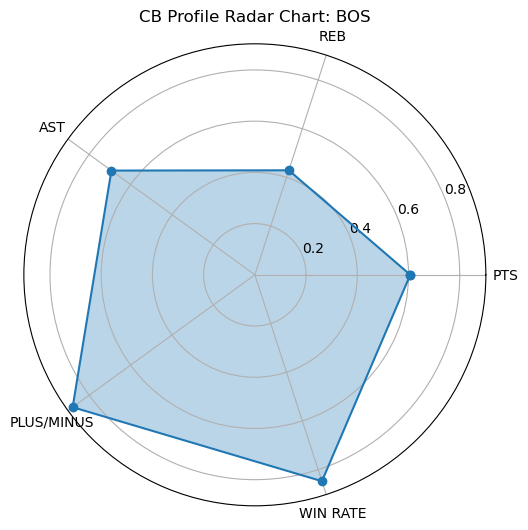

In [26]:
team_target = "1610612738"  # example

row = team_profile_scaled.filter(F.col("teamid") == team_target).toPandas().iloc[0]

labels = ["PTS", "REB", "AST", "PLUS/MINUS", "WIN RATE"]
values = row["cb_features"].tolist()
values = values + [values[0]]  # close the loop

angles = np.linspace(0, 2 * np.pi, len(labels) + 1)

plt.figure(figsize=(6,6))
plt.polar(angles, values, marker='o')
plt.fill(angles, values, alpha=0.3)
plt.title(f"CB Profile Radar Chart: {row['team']}")
plt.xticks(angles[:-1], labels)
plt.show()


### 4. Hybrid Score vs Win Rate Scatter Plot

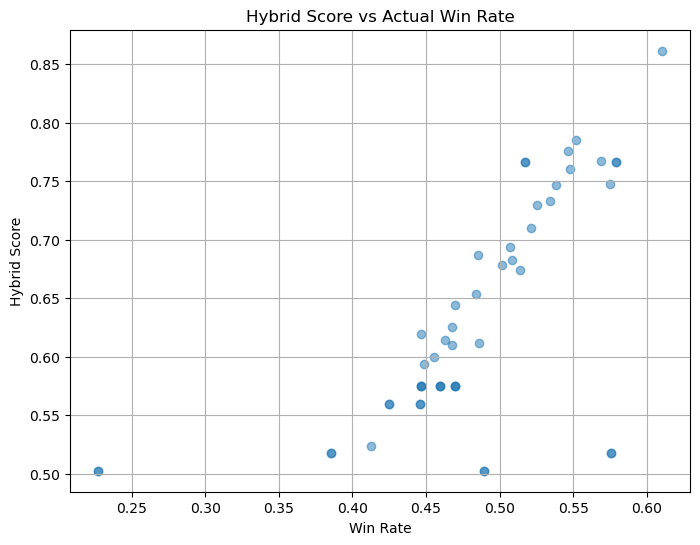

In [27]:
joined = (
    team_profile.alias("p")
    .join(team_strength_named.alias("s"), F.col("p.teamid") == F.col("s.team_a"))
    .select(
        F.col("p.team").alias("team_name"),
        F.col("p.win_rate").alias("win_rate"),
        F.col("s.avg_hybrid_score").alias("avg_hybrid_score")
    )
    .toPandas()
)

plt.figure(figsize=(8, 6))
plt.scatter(joined["win_rate"], joined["avg_hybrid_score"], alpha=0.5)
plt.title("Hybrid Score vs Actual Win Rate")
plt.xlabel("Win Rate")
plt.ylabel("Hybrid Score")
plt.grid(True)
plt.show()


### 6. Temporal Trends : (1) Average Points per Season

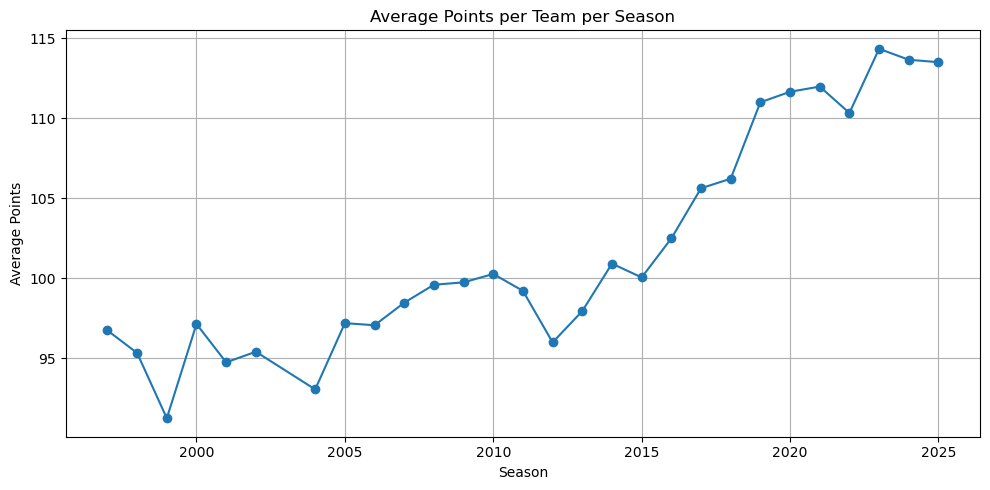

,season,avg_points
0,1997,96.734734
1,1998,95.326984
2,1999,91.250316
3,2000,97.138054
4,2001,94.742857
5,2002,95.406349
6,2004,93.051534
7,2005,97.191400
8,2006,97.061410
9,2007,98.467914


In [28]:
# Ensure date is parsed correctly
df_dates = df.withColumn("year", F.year("date"))

# Compute average points per season
season_trend = (
    df_dates.groupBy("season")
            .agg(F.avg("PTS").alias("avg_points"))
            .orderBy("season")
            .toPandas()
)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(season_trend["season"], season_trend["avg_points"], marker='o')
plt.title("Average Points per Team per Season")
plt.xlabel("Season")
plt.ylabel("Average Points")
plt.grid(True)
plt.tight_layout()
plt.show()

season_trend


### 6.2 Total League Points per Season

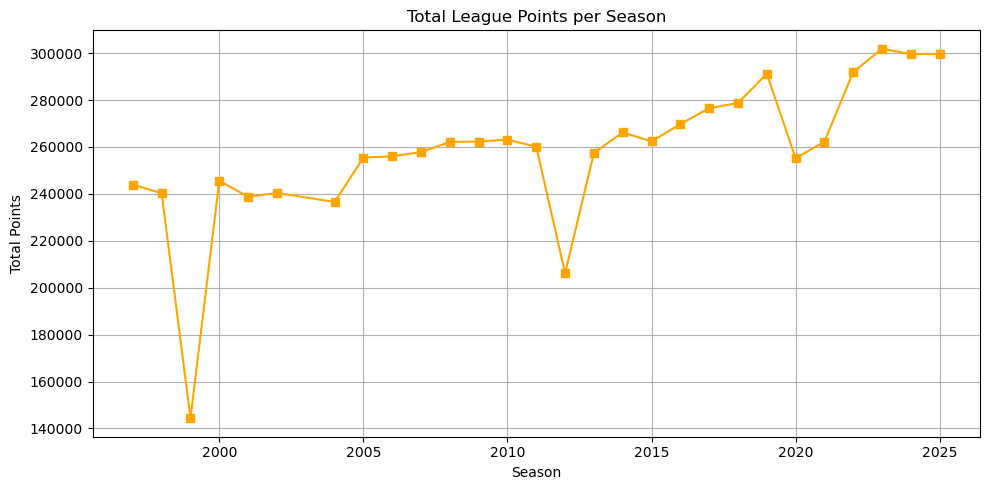

In [30]:
league_points = (
    df_dates.groupBy("season")
            .agg(F.sum("PTS").alias("total_points"))
            .orderBy("season")
            .toPandas()
)

plt.figure(figsize=(10, 5))
plt.plot(league_points["season"], league_points["total_points"], marker='s', color='orange')
plt.title("Total League Points per Season")
plt.xlabel("Season")
plt.ylabel("Total Points")
plt.grid(True)
plt.tight_layout()
plt.show()
